In [8]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np

In [9]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))
print(tf.test.is_built_with_cuda())
# checking complete 

2.21.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
True


In [10]:
# --- Configuration ---
IMAGE_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 50
CHANNELS = 3
n_classes = 3

In [11]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/mnt/c/development/Thesis/PotatoDiseaseClassification-CNN/DataSets/PlantVillage",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)
class_names = dataset.class_names

Found 2152 files belonging to 3 classes.


In [12]:
# --- Dataset Partitioning Function ---
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    return train_ds, val_ds, test_ds

In [13]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [14]:
# --- Performance Tuning ---
train_ds = train_ds.shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [15]:
# --- Preprocessing & Augmentation Layers ---
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])

In [16]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])


In [17]:

# --- Building Parallel Depth-CNN using Functional API ---
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
inputs = layers.Input(shape=input_shape)

# Apply preprocessing
x = resize_and_rescale(inputs)
x = data_augmentation(x)

# Parallel Branch 1: 3x3 Kernel
branch_3x3 = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
branch_3x3 = layers.MaxPooling2D((2, 2))(branch_3x3)

# Parallel Branch 2: 5x5 Kernel
branch_5x5 = layers.Conv2D(32, (5, 5), padding='same', activation='relu')(x)
branch_5x5 = layers.MaxPooling2D((2, 2))(branch_5x5)

# Parallel Branch 3: 7x7 Kernel
branch_7x7 = layers.Conv2D(32, (7, 7), padding='same', activation='relu')(x)
branch_7x7 = layers.MaxPooling2D((2, 2))(branch_7x7)

# Concatenate all parallel branches
merged = layers.Concatenate()([branch_3x3, branch_5x5, branch_7x7])

In [18]:
# Deep Feature Extraction
x = layers.Conv2D(64, (3, 3), activation='relu')(merged)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

# Fully Connected Layers
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(n_classes, activation='softmax')(x)

In [19]:
# Create Model
model = models.Model(inputs=inputs, outputs=outputs)

In [20]:
# --- Model Summary & Compilation ---
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 256, 256,  │          0 │ sequential[0][0]  │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ sequential_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,432 │ sequential_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │      4,736 │ sequential_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ max_pooling2d[0]… │
│ (Concatenate)       │ 96)               │            │ max_pooling2d_1[… │
│                     │                   │            │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 126, 126,  │     55,360 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 63, 63,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 61, 61,    │     36,928 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 30, 30,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 57600)     │          0 │ max_pooling2d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │  3,686,464 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        195 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 3,787,011 (14.45 MB)

 Trainable params: 3,787,011 (14.45 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)


In [22]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/50


W0000 00:00:1778259521.664247   98090 cpu_allocator_impl.cc:82] Allocation of 14745600 exceeds 10% of free system memory.
I0000 00:00:1778259539.090173   99851 shuffle_dataset_op.cc:453] ShuffleDatasetV3:20: Filling up shuffle buffer (this may take a while): 338 of 10000
I0000 00:00:1778259542.747118   99851 shuffle_dataset_op.cc:483] Shuffle buffer filled.
I0000 00:00:1778259542.756506   99851 shuffle_dataset_op.cc:483] Shuffle buffer filled.
I0000 00:00:1778259545.867687   98686 cuda_dnn.cc:461] Loaded cuDNN version 92101


430/430 ━━━━━━━━━━━━━━━━━━━━ 59s 58ms/step - accuracy: 0.7512 - loss: 0.6109 - val_accuracy: 0.8160 - val_loss: 0.5473
Epoch 2/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - accuracy: 0.8628 - loss: 0.3474 - val_accuracy: 0.9245 - val_loss: 0.2197
Epoch 3/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - accuracy: 0.9041 - loss: 0.2557 - val_accuracy: 0.8868 - val_loss: 0.2546
Epoch 4/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - accuracy: 0.9052 - loss: 0.2462 - val_accuracy: 0.9151 - val_loss: 0.2570
Epoch 5/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - accuracy: 0.9145 - loss: 0.2324 - val_accuracy: 0.9292 - val_loss: 0.1796
Epoch 6/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.9227 - loss: 0.1948 - val_accuracy: 0.9623 - val_loss: 0.1034
Epoch 7/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - accuracy: 0.9320 - loss: 0.1725 - val_accuracy: 0.9340 - val_loss: 0.1365
Epoch 8/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - accuracy: 0.9494 - loss: 0.1463 - val_accurac

In [23]:
# --- Evaluation & Visualization ---
scores = model.evaluate(test_ds)

# Accuracy & Loss Plots
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9636 - loss: 0.0802


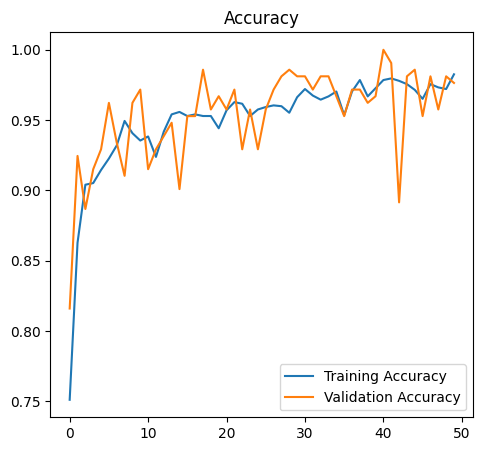

In [24]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

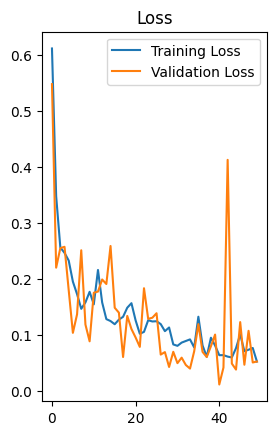

In [25]:
plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [27]:
# --- Saving Model ---
model_version = "Parallel_CNN_v1"
model.save(f"/mnt/c/development/Thesis/PotatoDiseaseClassification-CNN/models/{model_version}.keras")

W0000 00:00:1778261450.739343   98090 cpu_allocator_impl.cc:82] Allocation of 14745600 exceeds 10% of free system memory.
W0000 00:00:1778261450.884984   98090 cpu_allocator_impl.cc:82] Allocation of 14745600 exceeds 10% of free system memory.
W0000 00:00:1778261450.929756   98090 cpu_allocator_impl.cc:82] Allocation of 14745600 exceeds 10% of free system memory.
